In [2]:
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.base.datetools import dates_from_str
from statsmodels.tsa.api import VARMAX
import pandas as pd
from sklearn.decomposition import PCA

In [3]:
unscaled_data = pd.read_csv('normalized-perchip-arcsinh.csv', index_col=0)
model = PCA(n_components = 10)
reduced = model.fit_transform(unscaled_data)
print(reduced.shape)

(36, 10)


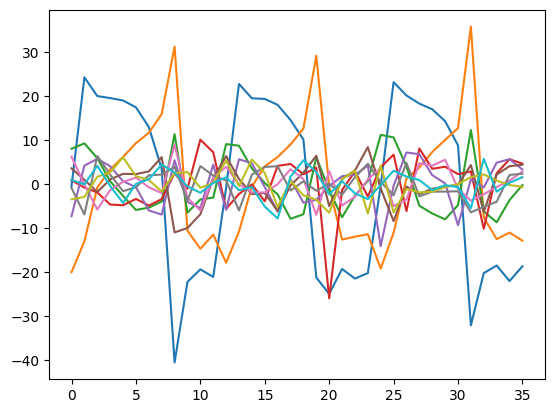

In [13]:
plt.plot(np.arange(36), reduced)
plt.show()

In [11]:
best_AIC = np.inf
best_sol = None
best_p, best_q = None, None
p_max = 3
q_max = 3

#Find the best model according to AIC
for p in range(1, p_max + 1):
    for q in range(1, q_max + 1):
        print(f'Iterating with p = {p}, q = {q}')
        model = VARMAX(reduced, order=(p,0, q),trend='c').fit(method='bfgs')
        AIC = model.aic
        if AIC < best_AIC:
            best_AIC = AIC
            best_p = p
            best_q = q
best_model = VARMAX(reduced, order=(best_p,0, best_q),trend='c').fit(method='bfgs')

Iterating with p = 1, q = 1


/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 22.738199
         Iterations: 0
         Function evaluations: 42
         Gradient evaluations: 31
Iterating with p = 1, q = 2


/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 22.738199
         Iterations: 0
         Function evaluations: 38
         Gradient evaluations: 27
Iterating with p = 1, q = 3


...

         Current function value: 19.737209
         Iterations: 0
         Function evaluations: 42
         Gradient evaluations: 30
Iterating with p = 2, q = 3


/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 19.737209
         Iterations: 0
         Function evaluations: 51
         Gradient evaluations: 39
Iterating with p = 3, q = 1


/Users/wyattwimmer/Desktop/hmm_gene_model/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/varmax.py:373: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


LinAlgError: Matrix is not positive definite

In [ ]:
print(best_p, best_q)